In [1]:
import warnings
from pathlib import Path


from datetime import datetime, timedelta, timezone
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


from scipy import stats
from scipy.optimize import minimize

from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.holtwinters import ExponentialSmoothing

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

## functions for unit root test and heteroskedasticity

In [2]:

def unit_root_summary(y, name="series"):
    rows = []
    for reg, label in [("c", "constant"), ("ct", "constant + trend")]:
        try:
            adf_res = adfuller(y, regression=reg, autolag="AIC")
            rows.append({
                "series": name,
                "test": f"ADF ({label})",
                "stat": adf_res[0],
                "pvalue": adf_res[1],
                "usedlag": adf_res[2]
            })
        except Exception as e:
            rows.append({
                "series": name,
                "test": f"ADF ({label})",
                "stat": np.nan,
                "pvalue": np.nan,
                "usedlag": np.nan
            })
        try:
            kpss_res = kpss(y, regression=reg, nlags="auto")
            rows.append({
                "series": name,
                "test": f"KPSS ({label})",
                "stat": kpss_res[0],
                "pvalue": kpss_res[1],
                "usedlag": kpss_res[2]
            })
        except Exception:
            rows.append({
                "series": name,
                "test": f"KPSS ({label})",
                "stat": np.nan,
                "pvalue": np.nan,
                "usedlag": np.nan
            })
    return pd.DataFrame(rows)

def arch_lm_table(y, nlags=4):
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(y, nlags=nlags)
    return pd.DataFrame({
        "LM stat": [lm_stat],
        "LM p-value": [lm_pvalue],
        "F stat": [f_stat],
        "F p-value": [f_pvalue],
        "lags": [nlags]
    })

def plot_hist_density_qq(y, title_prefix="Series"):
    yy = np.asarray(y)
    mu, sig = yy.mean(), yy.std(ddof=0)
    x = np.linspace(mu - 4*sig, mu + 4*sig, 400)

    plt.figure(figsize=(10,5))
    plt.hist(yy, bins=30, density=True, alpha=0.5, label="Histogram")
    kde = stats.gaussian_kde(yy)
    plt.plot(x, kde(x), linewidth=2, label="Kernel density")
    plt.plot(x, stats.norm.pdf(x, loc=mu, scale=sig), linewidth=2, label="Normal density")
    plt.title(f"{title_prefix}: histogram, kernel density, and normal density")
    plt.tight_layout()
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,5))
    stats.probplot(yy, dist="norm", plot=plt)
    plt.title(f"{title_prefix}: Normal Q-Q plot")
    plt.tight_layout()
    plt.show()

def get_param(fit, *candidates, default=np.nan):
    names = list(getattr(fit, "param_names", []))
    params = np.asarray(fit.params)
    for c in candidates:
        if c in names:
            return float(params[names.index(c)])
    return default

def fit_arch1(y):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    n = len(y)
    var0 = np.var(y)
    def unpack(u):
        omega = np.exp(u[0])
        ea = np.exp(u[1])
        alpha = ea / (1 + ea)
        return omega, alpha
    def nll(u):
        omega, alpha = unpack(u)
        h = np.empty(n)
        h[0] = max(var0, omega / max(1e-6, 1-alpha))
        for t in range(1, n):
            h[t] = omega + alpha * y[t-1]**2
        return 0.5 * np.sum(np.log(h) + y**2 / h)
    res = minimize(nll, [np.log(var0*0.1), np.log(0.1/0.9)], method="L-BFGS-B")
    omega, alpha = unpack(res.x)
    h = np.empty(n)
    h[0] = max(var0, omega / max(1e-6, 1-alpha))
    for t in range(1, n):
        h[t] = omega + alpha * y[t-1]**2
    ll = -nll(res.x)
    return {
        "omega": omega, "alpha": alpha, "loglik": ll, "aic": 2*2 - 2*ll,
        "bic": np.log(n)*2 - 2*ll, "h": h, "resid": y/np.sqrt(h), "centered_y": y,
        "success": res.success
    }

def fit_garch11(y):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    n = len(y)
    var0 = np.var(y)
    def unpack(u):
        omega = np.exp(u[0])
        ea, eb = np.exp(u[1]), np.exp(u[2])
        s = 1 + ea + eb
        alpha = ea / s
        beta = eb / s
        return omega, alpha, beta
    def nll(u):
        omega, alpha, beta = unpack(u)
        h = np.empty(n)
        h[0] = max(var0, omega / max(1e-6, 1-alpha-beta))
        for t in range(1, n):
            h[t] = omega + alpha * y[t-1]**2 + beta * h[t-1]
        return 0.5 * np.sum(np.log(h) + y**2 / h)
    starts = [
        [np.log(var0*0.01), np.log(0.07/0.03), np.log(0.90/0.03)],
        [np.log(var0*0.10), np.log(0.05/0.05), np.log(0.90/0.05)],
        [np.log(var0*0.01), np.log(0.10/0.10), np.log(0.80/0.10)],
    ]
    best = None
    for s in starts:
        r = minimize(nll, s, method="L-BFGS-B")
        if best is None or r.fun < best.fun:
            best = r
    omega, alpha, beta = unpack(best.x)
    h = np.empty(n)
    h[0] = max(var0, omega / max(1e-6, 1-alpha-beta))
    for t in range(1, n):
        h[t] = omega + alpha * y[t-1]**2 + beta * h[t-1]
    ll = -nll(best.x)
    return {
        "omega": omega, "alpha": alpha, "beta": beta, "loglik": ll, "aic": 2*3 - 2*ll,
        "bic": np.log(n)*3 - 2*ll, "h": h, "resid": y/np.sqrt(h), "centered_y": y,
        "success": best.success
    }

def garch_forecast_path(fit_dict, y, steps=10):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    omega = fit_dict["omega"]
    alpha = fit_dict.get("alpha", 0.0)
    beta = fit_dict.get("beta", 0.0)
    h_last = fit_dict["h"][-1]
    y_last = y[-1]
    out = np.empty(steps)
    out[0] = omega + alpha * y_last**2 + beta * h_last
    for k in range(1, steps):
        out[k] = omega + (alpha + beta) * out[k-1]
    return out


In [3]:
# Forecast horizon
FORECAST_START = '2026-04-20'
FORECAST_END = '2026-04-24'

TARGET_KEY = 'AVX'
TARGET_LABEL = "VIX"

FORECAST_DATES = pd.date_range(FORECAST_START, FORECAST_END, freq='D')
H = len(FORECAST_DATES)

In [4]:

def to_2col_array(ci):
    """Return conf_int as a (h,2) numpy array, robust to DataFrame/ndarray."""
    return np.asarray(ci)

def plot_series(y, title, xlabel="t", ylabel="value"):
    plt.figure(figsize=(10,5))
    x_axis = y.index if hasattr(y, "index") else np.arange(1, len(y)+1)
    y_vals = y.values if hasattr(y, "values") else y
    plt.plot(x_axis, y_vals, linewidth=1)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_acf_pacf(y, nlags=24, pacf_method="ywm"):
    yy = np.asarray(y)
    n = len(yy)
    nlags = min(nlags, n//2 - 1)
    nlags = max(nlags, 1)

    r = acf(yy, nlags=nlags, fft=False)
    p = pacf(yy, nlags=nlags, method=pacf_method)

    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample ACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), p, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample PACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    return r, p

def residual_report(fit, lags=(8,12,16,20)):
    resid = np.asarray(fit.resid)
    lb = acorr_ljungbox(resid, lags=list(lags), return_df=True)
    return resid, lb

def plot_resid_acf(resid, nlags=24, title="Residual ACF"):
    rr = np.asarray(resid)
    n = len(rr)
    nlags = min(nlags, n - 1)

    r = acf(rr, nlags=nlags, fft=False)
    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"{title} (bands = ±1.96/√n, n={n})")
    plt.tight_layout()
    plt.show()

def forecast_table_and_plot(fit, steps, y, title_prefix="Forecast"):
    fc = fit.get_forecast(steps=steps)
    mean_fc = np.asarray(fc.predicted_mean)
    ci_arr = to_2col_array(fc.conf_int(alpha=0.05))

    n = len(y)
    idx = np.arange(n+1, n+steps+1)
    fc_df = pd.DataFrame({
        "forecast": mean_fc,
        "lower_95": ci_arr[:,0],
        "upper_95": ci_arr[:,1],
    }, index=idx)

    plt.figure(figsize=(10,5))
    plt.plot(np.arange(1, n+1), np.asarray(y), label="observed", linewidth=1)
    t_fc = np.arange(n+1, n+steps+1)
    plt.plot(t_fc, mean_fc, label="forecast", linewidth=2)
    plt.fill_between(t_fc, ci_arr[:,0], ci_arr[:,1], alpha=0.2, label="95% PI")
    plt.title(f"{title_prefix}")
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

    return fc_df

def ets_benchmarks(y, seasonal_periods=None, seasonal=None):
    yy = pd.Series(y).astype(float)
    ses = ExponentialSmoothing(yy, trend=None, seasonal=None).fit(optimized=True)
    holt = ExponentialSmoothing(yy, trend="add", seasonal=None, damped_trend=False).fit(optimized=True)
    hw = None
    if seasonal_periods is not None and seasonal is not None:
        hw = ExponentialSmoothing(yy, trend="add", seasonal=seasonal,
                                  seasonal_periods=seasonal_periods).fit(optimized=True)
    return ses, holt, hw

def plot_ets_forecasts(y, steps, ses, holt, hw=None, title="ETS benchmarks"):
    yy = np.asarray(y)
    n = len(yy)
    t = np.arange(1, n+1)
    t_fc = np.arange(n+1, n+steps+1)

    f_ses = ses.forecast(steps)
    f_holt = holt.forecast(steps)

    plt.figure(figsize=(10,5))
    plt.plot(t, yy, label="observed", linewidth=1)
    plt.plot(t_fc, f_ses, label="SES", linewidth=2)
    plt.plot(t_fc, f_holt, label="Holt", linewidth=2)
    if hw is not None:
        f_hw = hw.forecast(steps)
        plt.plot(t_fc, f_hw, label="Holt-Winters", linewidth=2)

    plt.title(title)
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

def forecast_df(fit, steps, n_obs):
    fc = fit.get_forecast(steps=steps)
    mean_fc = np.asarray(fc.predicted_mean)
    ci = np.asarray(fc.conf_int(alpha=0.05))
    idx = np.arange(n_obs+1, n_obs+steps+1)
    return pd.DataFrame({
        "forecast": mean_fc,
        "lower_95": ci[:,0],
        "upper_95": ci[:,1]
    }, index=idx)

def forecast_plot(y, fc_df, title="Forecast with 95% PI"):
    y = np.asarray(y)
    n = len(y)
    t = np.arange(1, n+1)
    t_fc = fc_df.index.values
    plt.figure(figsize=(10,5))
    plt.plot(t, y, label="observed", linewidth=1.5)
    plt.plot(t_fc, fc_df["forecast"].values, label="forecast", linewidth=2)
    plt.fill_between(t_fc, fc_df["lower_95"].values, fc_df["upper_95"].values, alpha=0.2, label="95% PI")
    plt.title(title)
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()


In [5]:
def _default_range(days=3*365):
    end = datetime.now(timezone.utc).date()
    start = end - timedelta(days=days)
    return start.isoformat(), end.isoformat()


def _inclusive_end_for_yf(end_str):
    end_dt = datetime.strptime(end_str, "%Y-%m-%d").date()
    inclusive_plus = end_dt + timedelta(days=1)
    return inclusive_plus.isoformat()


def get_vix_df(start: str = None, end: str = None, days: int = 365, symbol: str = "^VIX") -> pd.DataFrame:
    """
    Fetch VIX adjusted close and return a DataFrame aligned to a daily calendar.

    Returns:
      pandas.DataFrame with columns ['date', symbol] where 'date' is dtype datetime64[ns].
    """
    if start is None or end is None:
        default_start, default_end = _default_range(days)
        start = start or default_start
        end = end or default_end

    try:
        _ = datetime.strptime(start, "%Y-%m-%d")
        _ = datetime.strptime(end, "%Y-%m-%d")
    except ValueError:
        raise ValueError("start and end must be in YYYY-MM-DD format")

    yf_end = _inclusive_end_for_yf(end)

    df = yf.download(symbol, start=start, end=yf_end, auto_adjust=True, progress=False)

    date_index = pd.date_range(start=start, end=end, freq="D")

    # If empty, return calendar with NaN floats
    if df is None or df.empty:
        out = pd.DataFrame({"date": date_index, symbol: np.nan})
        out["date"] = pd.to_datetime(out["date"])
        return out

    # If yfinance returned MultiIndex columns (e.g., ('Close', '^VIX')), flatten them
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ["_".join([str(c) for c in col if c is not None]).strip() for col in df.columns.values]

    # Prefer 'Close' (auto_adjust=True makes it adjusted), fallback to 'Adj Close', else first numeric
    if "Close" in df.columns:
        series = df[["Close"]].rename(columns={"Close": symbol})
    elif "Adj Close" in df.columns:
        series = df[["Adj Close"]].rename(columns={"Adj Close": symbol})
    else:
        numeric_cols = df.select_dtypes(include="number").columns
        if len(numeric_cols) == 0:
            out = pd.DataFrame({"date": date_index, symbol: np.nan})
            out["date"] = pd.to_datetime(out["date"])
            return out
        first_col = numeric_cols[0]
        series = df[[first_col]].rename(columns={first_col: symbol})

    # Align to full calendar
    series.index = pd.to_datetime(series.index).normalize()
    aligned = series.reindex(date_index)
    aligned.index.name = "date"
    aligned = aligned.reset_index()


def get_vix_df(start: str = None, end: str = None, days: int = 365, symbol: str = "^VIX") -> pd.DataFrame:
    """
    Fetch VIX adjusted close and return a DataFrame aligned to a daily calendar.

    Returns:
      pandas.DataFrame with columns ['date', 'value'] where 'date' is dtype datetime64[ns].
    """
    if start is None or end is None:
        default_start, default_end = _default_range(days)
        start = start or default_start
        end = end or default_end

    try:
        _ = datetime.strptime(start, "%Y-%m-%d")
        _ = datetime.strptime(end, "%Y-%m-%d")
    except ValueError:
        raise ValueError("start and end must be in YYYY-MM-DD format")

    yf_end = _inclusive_end_for_yf(end)
    df = yf.download(symbol, start=start, end=yf_end, auto_adjust=True, progress=False)

    date_index = pd.date_range(start=start, end=end, freq="D")

    # If empty, return calendar with NaN floats under 'value'
    if df is None or df.empty:
        out = pd.DataFrame({"date": date_index, "VIX": np.nan})
        out["date"] = pd.to_datetime(out["date"])
        return out

    # Flatten MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ["_".join([str(c) for c in col if c is not None]).strip() for col in df.columns.values]

    # Pick the appropriate column and rename to a temporary name
    if "Close" in df.columns:
        series = df[["Close"]].rename(columns={"Close": "tmp_value"})
    elif "Adj Close" in df.columns:
        series = df[["Adj Close"]].rename(columns={"Adj Close": "tmp_value"})
    else:
        numeric_cols = df.select_dtypes(include="number").columns
        if len(numeric_cols) == 0:
            out = pd.DataFrame({"date": date_index, "VIX": np.nan})
            out["date"] = pd.to_datetime(out["date"])
            return out
        first_col = numeric_cols[0]
        series = df[[first_col]].rename(columns={first_col: "tmp_value"})

    # Align to full calendar
    series.index = pd.to_datetime(series.index).normalize()
    aligned = series.reindex(date_index)
    aligned.index.name = "date"
    aligned = aligned.reset_index()

    # Finalize columns: rename tmp_value to 'value'
    aligned["date"] = pd.to_datetime(aligned["date"])
    aligned = aligned.rename(columns={"tmp_value": "VIX"})
    aligned["VIX"] = aligned["VIX"].astype(float)

    return aligned

In [25]:
df_live = get_vix_df(days = 365*10)
df_live.head(10)

,date,VIX
0,2016-04-04,14.1200
1,2016-04-05,15.4200
2,2016-04-06,14.0900
3,2016-04-07,16.1600
4,2016-04-08,15.3600
5,2016-04-09,NaN
6,2016-04-10,NaN
7,2016-04-11,16.2600
8,2016-04-12,14.8500
9,2016-04-13,13.8400


In [26]:

def process_live_df(df: pd.DataFrame, date_col: str, target_col: str) -> pd.Series:
    # 1. Clean and convert types
    out = df[[date_col, target_col]].copy()
    out[date_col] = pd.to_datetime(out[date_col], errors='coerce')
    out[target_col] = pd.to_numeric(out[target_col], errors='coerce')

    # 2. Drop invalid rows and sort chronologically
    out = out.dropna(subset=[date_col]).sort_values(date_col)

    # 3. Set date as index and force a Daily frequency
    s = out.set_index(date_col)[target_col].asfreq('D')

    s = s.interpolate(method='time').ffill().bfill()

    return s


In [27]:
series = process_live_df(df_live, 'date', TARGET_LABEL)

In [28]:
n_series = len(series)
print("Number of monthly observations:", n_series)
print("First 10 observations:", series[:10])
print("Last 10 observations:", series[-10:])

Number of monthly observations: 3651
First 10 observations: date
2016-04-04   14.1200
2016-04-05   15.4200
2016-04-06   14.0900
2016-04-07   16.1600
2016-04-08   15.3600
2016-04-09   15.6600
2016-04-10   15.9600
2016-04-11   16.2600
2016-04-12   14.8500
2016-04-13   13.8400
Freq: D, Name: VIX, dtype: float64
Last 10 observations: date
2026-03-24   26.9500
2026-03-25   25.3300
2026-03-26   27.4400
2026-03-27   31.0500
2026-03-28   30.9033
2026-03-29   30.7567
2026-03-30   30.6100
2026-03-31   25.2500
2026-04-01   24.5400
2026-04-02   24.5400
Freq: D, Name: VIX, dtype: float64


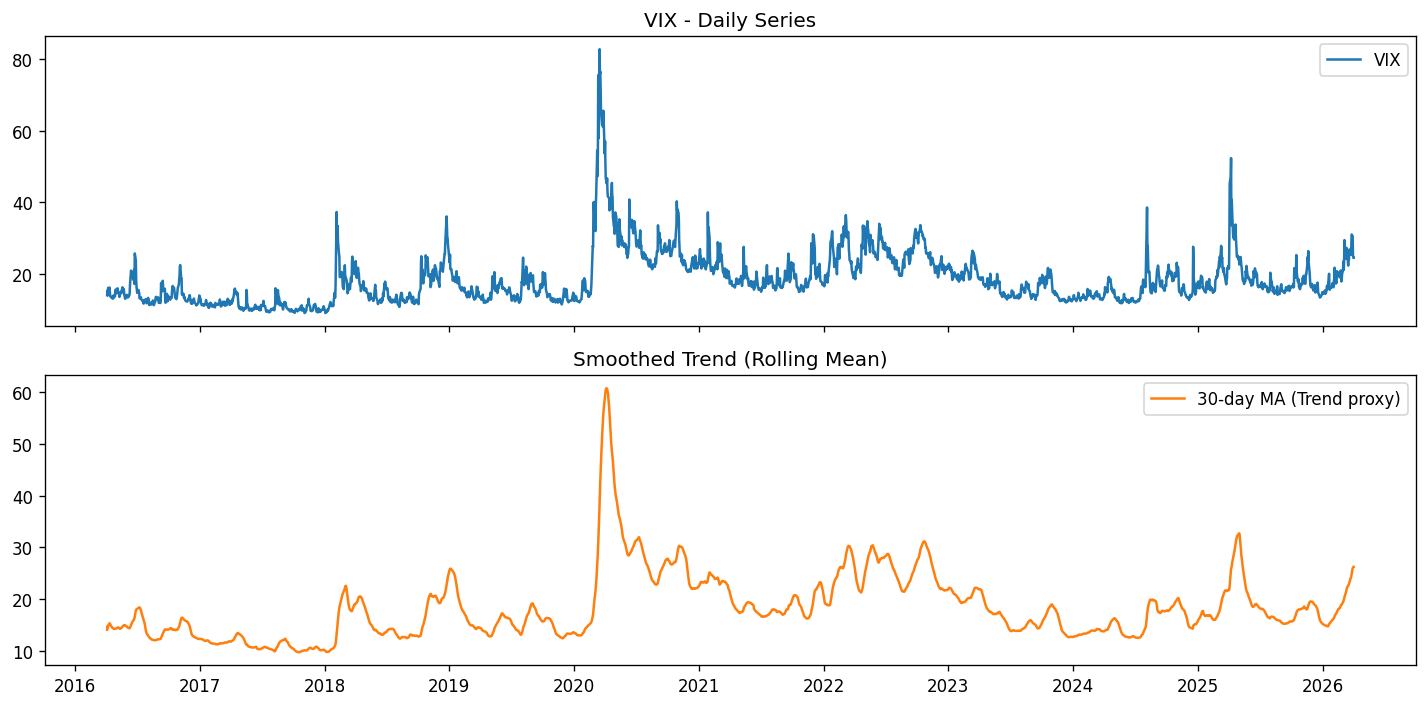

In [29]:
# -----------------------------
# VISUALIZATION
# -----------------------------

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(series.index, series.values, label=TARGET_LABEL)
axes[0].set_title(f'{TARGET_LABEL} - Daily Series')
axes[0].legend()

roll = series.rolling(30, min_periods=1).mean()
axes[1].plot(series.index, roll.values, color='tab:orange', label='30-day MA (Trend proxy)')
axes[1].set_title('Smoothed Trend (Rolling Mean)')
axes[1].legend()

plt.tight_layout()
plt.show()

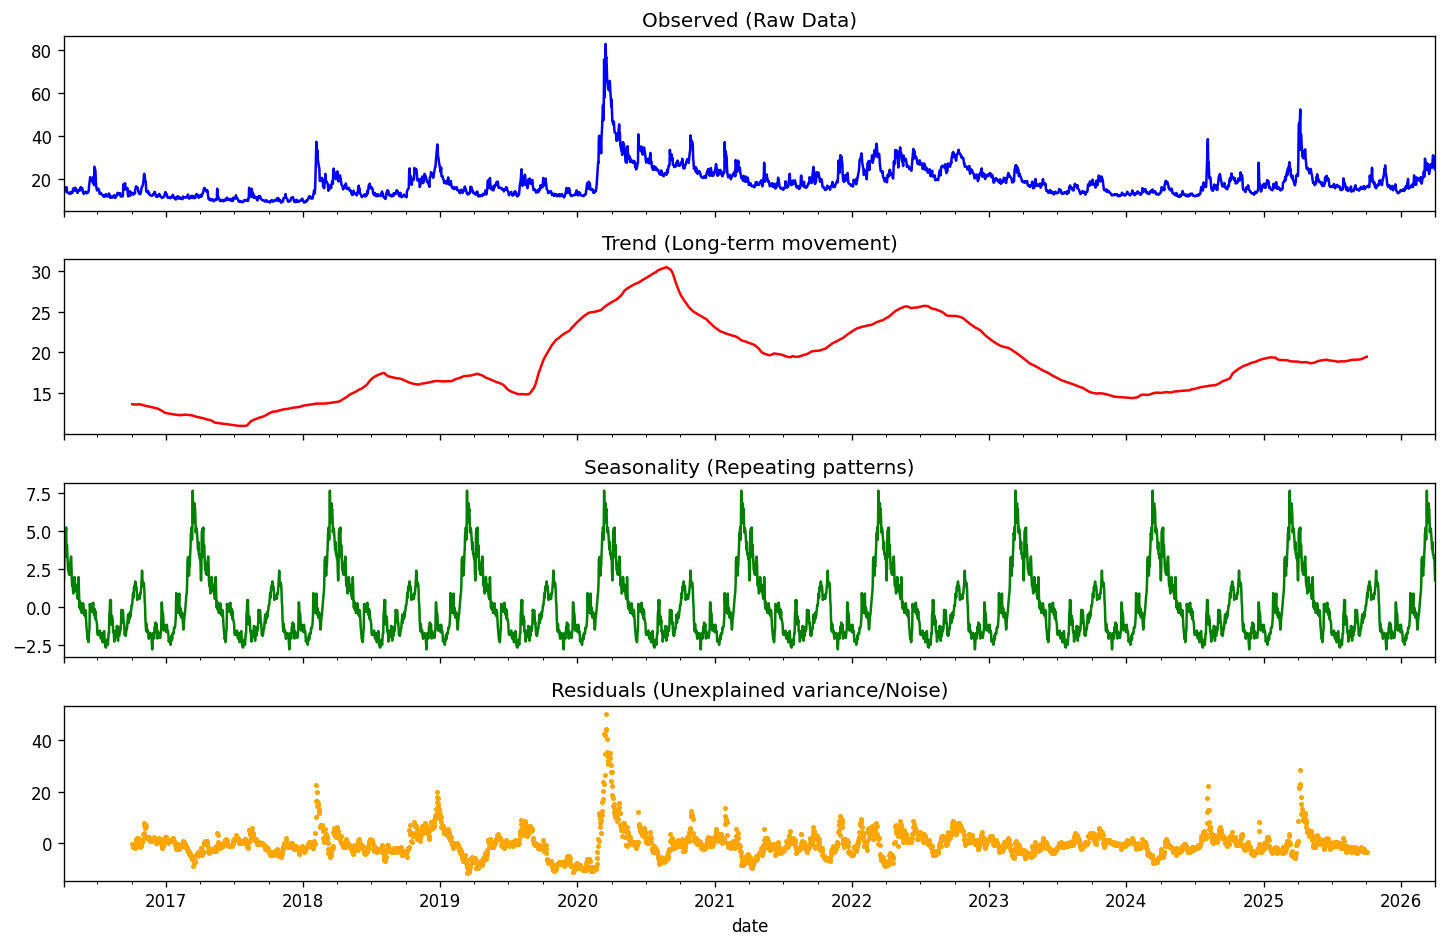

In [30]:
# -----------------------------
# PLOT TREND/SEASONALITY/RESIDUALS
# -----------------------------


result = seasonal_decompose(series, model='additive', period=int(365))


fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8), sharex=True)


result.observed.plot(ax=ax1, color='blue')
ax1.set_title('Observed (Raw Data)')

# Trend: The long-term progression of the series, stripping away short-term fluctuations.
result.trend.plot(ax=ax2, color='red')
ax2.set_title('Trend (Long-term movement)')

# Seasonal: Repeating patterns that occur over a fixed period (e.g., annual cycles).
result.seasonal.plot(ax=ax3, color='green')
ax3.set_title('Seasonality (Repeating patterns)')

# Residual: What’s left after removing trend and seasonality; the "noise" or "shocks."
result.resid.plot(ax=ax4, color='orange', style='o', markersize=2)
ax4.set_title('Residuals (Unexplained variance/Noise)')

plt.tight_layout()
plt.show()

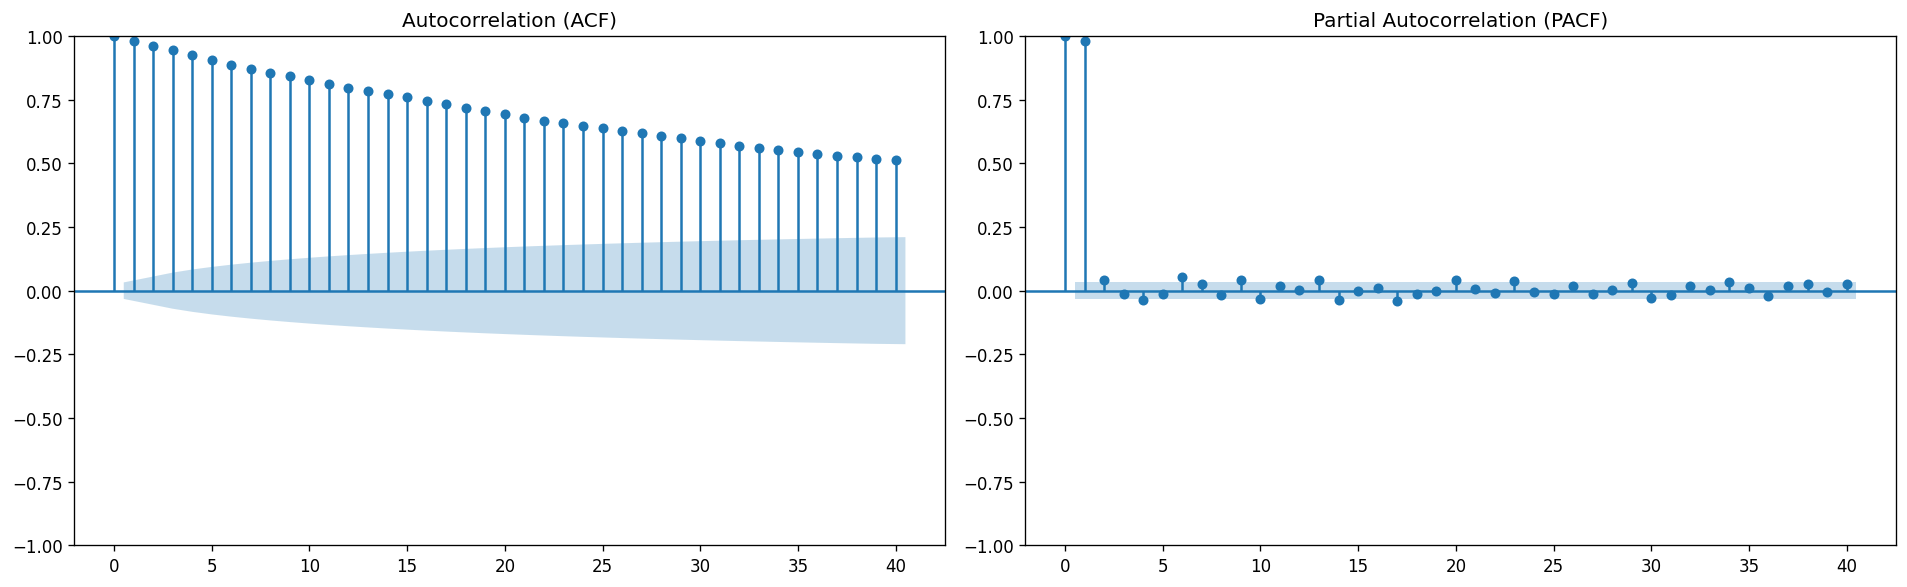

In [31]:
# -----------------------------
# PLOT ACF AND PACF
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF Plot
plot_acf(series, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')

# PACF Plot
plot_pacf(series, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.show()

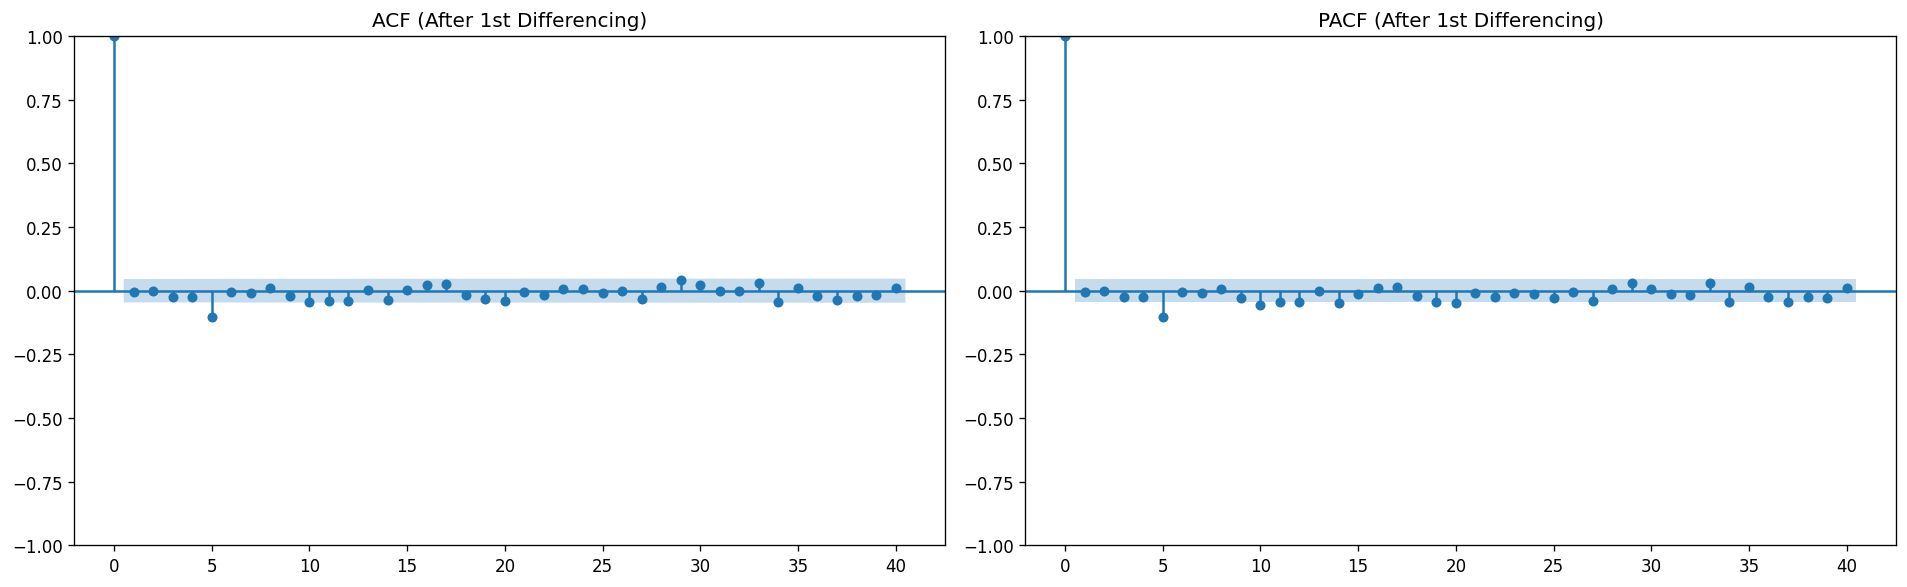

In [ ]:
# -----------------------------
# PLOT ACF AND PACF AFTER FIRST ORDER DIFFERENCING
# -----------------------------

# This calculates the change from one day to the next
series_diff = series.diff().dropna()

# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF Plot of Differenced Data
plot_acf(series_diff, lags=40, ax=axes[0])
axes[0].set_title('ACF (After 1st Differencing)')

# PACF Plot of Differenced Data
plot_pacf(series_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF (After 1st Differencing)')

plt.tight_layout()
plt.show()

The Lag 0 Spike: This is always 1.0 (a variable is 100% correlated with itself).
The Cutoff at Lag 1: Because there are no significant spikes at lag 1, 2, or beyond, it means that yesterday's change has zero predictive power over today's change.
The Conclusion: "The first-order differenced VIX series is White Noise. This proves the original VIX follows a Random Walk process."


Since we differenced once => d = 1,
from the plots, PACF and ACF = 0,0

In [ ]:
print("Unit root test summary: Δ VIX")
display(unit_root_summary(series_diff, name="d1_VIX"))

Unit root test summary: Δ VIX


C:\Users\vyass\AppData\Local\Temp\ipykernel_28552\1800738326.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
C:\Users\vyass\AppData\Local\Temp\ipykernel_28552\1800738326.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,d1_VIX,ADF (constant),-14.100122,2.627714e-26,13
1,d1_VIX,KPSS (constant),0.044840,1.000000e-01,22
2,d1_VIX,ADF (constant + trend),-14.100980,8.939852e-22,13
3,d1_VIX,KPSS (constant + trend),0.027718,1.000000e-01,22


Because the ACF decayed slowly, we applied first-order differencing. Since the PACF of the differenced data showed no significant lags other than at lag 5, Our initial "naive" guess is an ARIMA(0,1,0). This assumes tomorrow's VIX is just today's value plus random noise.

In [ ]:
# --- candidate ARIMA models (p,1,q) ---
candidates = [
    ("ARIMA(0,1,0)", (0,1,0), None),
    ("ARIMA(1,1,1)", (1,1,1), None),
    ("ARIMA(3,1,3)", (3,1,3), None),
    ("ARIMA(2,1,0)", (2,1,0), None),
    ("ARIMA(0,1,2)", (0,1,2), None),
    ("ARIMA(2,1,2)", (2,1,2), None),
    ("ARIMA(5,1,0)", (5,1,0), None),
    ("ARIMA(0,1,5)", (0,1,5), None),
    ("ARIMA(5,1,5)", (5,1,5), None),
    # seasonal candidates (weekly / 5 trading days)
]


# --- fit each candidate and keep the fitted results ---
fits = {}
rows = []
for name, order, seasonality in candidates:
    m = ARIMA(series, order=order, trend="n").fit()
    fits[name] = (m, order)
    rows.append({
        "model": name,
        "order": order,
        "AIC": m.aic,
        "BIC": m.bic
    })

# --- comparison table sorted by AIC ---
cmp = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
cmp

c:\Users\vyass\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\vyass\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\vyass\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\vyass\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn

,model,order,AIC,BIC
0,"ARIMA(5,1,5)","(5, 1, 5)",6245.966187,6306.568874
1,"ARIMA(3,1,3)","(3, 1, 3)",6251.975664,6290.541010
2,"ARIMA(2,1,2)","(2, 1, 2)",6252.326762,6279.873438
3,"ARIMA(0,1,5)","(0, 1, 5)",6261.079314,6294.135326
4,"ARIMA(5,1,0)","(5, 1, 0)",6264.521898,6297.577910
5,"ARIMA(0,1,0)","(0, 1, 0)",6277.095098,6282.604433
6,"ARIMA(1,1,1)","(1, 1, 1)",6279.522159,6296.050165
7,"ARIMA(2,1,0)","(2, 1, 0)",6281.058157,6297.586163
8,"ARIMA(0,1,2)","(0, 1, 2)",6281.058243,6297.586249


We pick model ARIMA(2,1,2) as its AIC is not that much greater than (5,1,5), and BIC is much lower.


### Step 5: Residual diagnostics for the selected mean model
The lecture notes emphasize that **AIC/BIC must always be paired with diagnostics**. Even a model with a good AIC is not acceptable if the residuals are clearly non-white.

In [ ]:
# --- select best model by AIC and retrieve its fitted result ---
best_name = "ARIMA(2,1,2)"
best_fit = fits.get(best_name)[0]

print("\nSelected model by AIC:", best_name)
if best_fit is None:
    raise RuntimeError(f"Best model {best_name} failed to fit.")
print(best_fit.summary())


Selected model by AIC: ARIMA(2,1,2)
                               SARIMAX Results                                
Dep. Variable:                    VIX   No. Observations:                 1826
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -3121.163
Date:                Mon, 30 Mar 2026   AIC                           6252.327
Time:                        15:57:25   BIC                           6279.873
Sample:                    03-31-2021   HQIC                          6262.488
                         - 03-30-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0749      0.245      0.306      0.759      -0.404       0.554
ar.L2          0.8115      0.228      3.562      0.000       0.365       1.258
ma.L1         -

,lb_stat,lb_pvalue
2,1.177691,0.554967
4,1.438403,0.837494
6,9.876158,0.129965
8,10.765663,0.215334


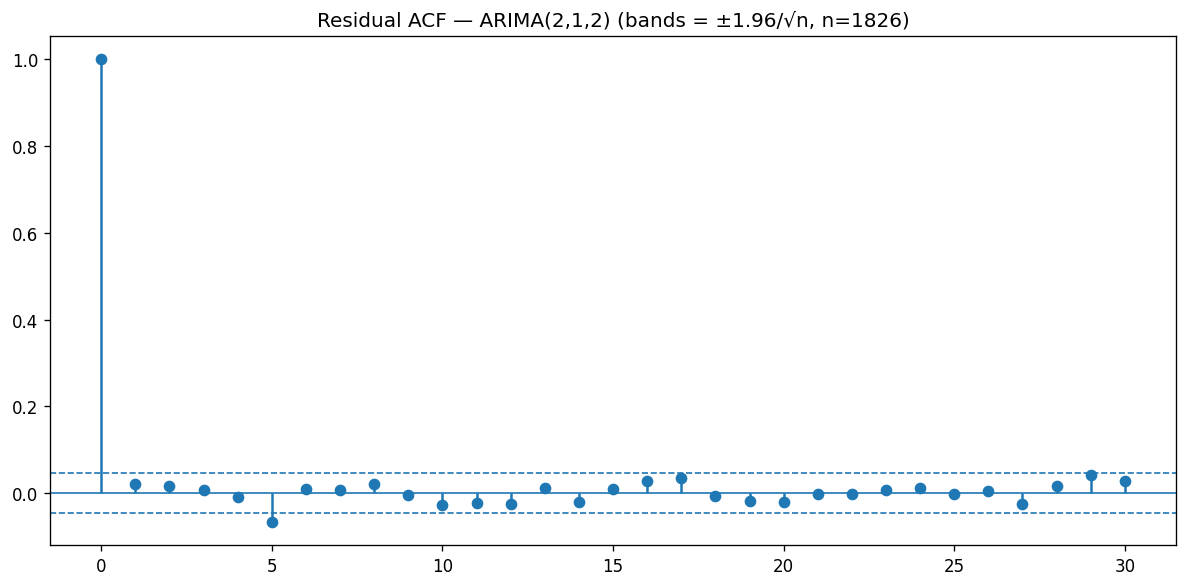

In [ ]:
# --- run your existing diagnostics functions on the selected fit ---
# assumes residual_report and plot_resid_acf are defined in your environment
resid, lb_vix = residual_report(best_fit, lags=(2,4,6,8))
display(lb_vix)
plot_resid_acf(resid, nlags=30, title=f"Residual ACF — {best_name}")


### Step 6: Forecasting the transformed mean model
We perform a simple holdout exercise on the last 6 days.


In [ ]:
best_order = fits[best_name][1]
best_order

(2, 1, 2)

In [ ]:
h = 6

# --- split ---
train = series[:-h]
test = series[-h:]   # kept for evaluation only, not used to generate forecasts


# --- fit on training data (ARIMA will difference d internally) ---
model = ARIMA(train, order=best_order, trend="n").fit()

# --- multi-step forecast that uses forecasted values recursively ---
# This call produces h-step-ahead forecasts without using actual future observations.
multi_forecast = model.forecast(steps=h)   # pandas Series indexed after train

# --- ensure forecast is a numpy array aligned with test order ---
forecast = np.asarray(multi_forecast)[:h]

# --- build fc_tbl with the requested index ---
fc_tbl = pd.DataFrame({
    "Actual": test.values,
    "Forecast": forecast
}, index=test.index)

# --- optional: print RMSE for quick check ---
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(test.values, forecast)
print(f"Holdout RMSE: {rmse:.6f}")

# --- display table ---
display(fc_tbl)

c:\Users\vyass\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\vyass\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Holdout RMSE: 4.462926


c:\Users\vyass\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Actual,Forecast
date,,
2026-03-25,25.330000,26.662109
2026-03-26,27.440001,26.274886
2026-03-27,31.049999,26.029257
2026-03-28,30.999999,25.682761
2026-03-29,30.949999,25.474133
2026-03-30,30.900000,25.163427


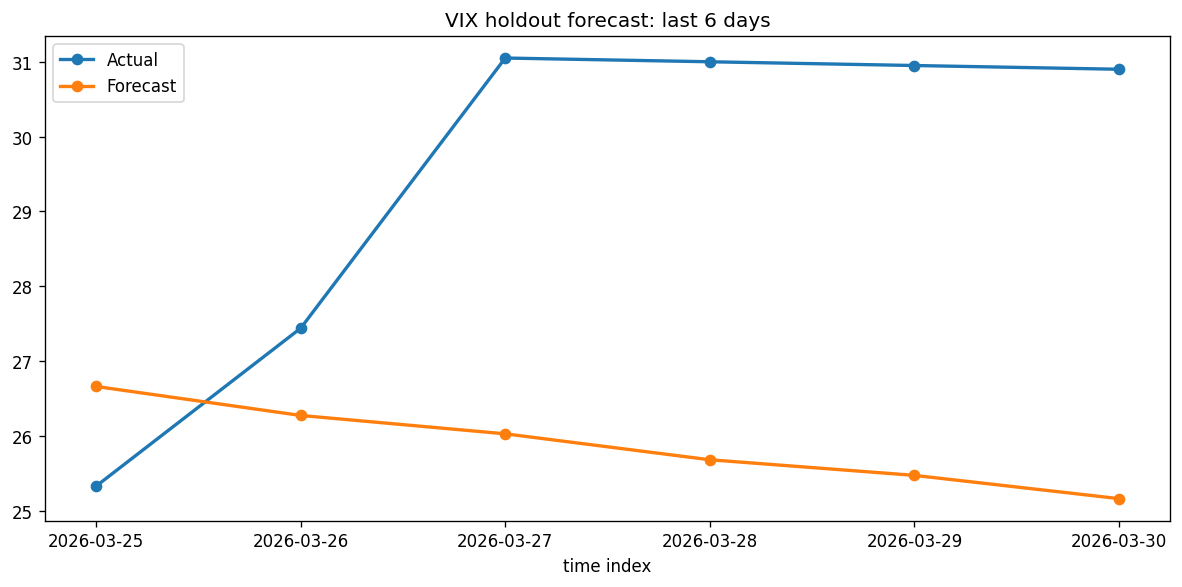

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(fc_tbl.index, fc_tbl["Actual"].values, marker="o", linewidth=2, label="Actual")
plt.plot(fc_tbl.index, fc_tbl["Forecast"].values, marker="o", linewidth=2, label="Forecast")
plt.title("VIX holdout forecast: last 6 days")
plt.xlabel("time index")
plt.tight_layout()
plt.legend()
plt.show()

### Diagnostics: Testing for ARCH Effects
We observed massive residual spikes in 2022 and 2025. We tested if these "shocks" had a predictable memory (Volatility Clustering).

### Testing for ARCH Effects (Heteroskedasticity)
We examine the residuals of our ARIMA(2,1,2) model. We want to know if the "size" of the errors in 2022 and 2025 is constant or if the variance changes over time.


### Step 2: ADF and KPSS on level and differenced series
We use ADF and KPSS again to separate the nonstationary level series from the transformed series used for modeling.


In [ ]:
print("Unit root test summary: exchange rate level")
display(unit_root_summary(series, name="VIX"))

print("Unit root test summary: first difference")
display(unit_root_summary(series_diff))

Unit root test summary: exchange rate level


C:\Users\vyass\AppData\Local\Temp\ipykernel_28552\1800738326.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
C:\Users\vyass\AppData\Local\Temp\ipykernel_28552\1800738326.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,VIX,ADF (constant),-4.630845,0.000113,5
1,VIX,KPSS (constant),1.106694,0.010000,26
2,VIX,ADF (constant + trend),-4.702388,0.000691,5
3,VIX,KPSS (constant + trend),0.447435,0.010000,26


Unit root test summary: first difference


C:\Users\vyass\AppData\Local\Temp\ipykernel_28552\1800738326.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
C:\Users\vyass\AppData\Local\Temp\ipykernel_28552\1800738326.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,series,ADF (constant),-14.100122,2.627714e-26,13
1,series,KPSS (constant),0.044840,1.000000e-01,22
2,series,ADF (constant + trend),-14.100980,8.939852e-22,13
3,series,KPSS (constant + trend),0.027718,1.000000e-01,22


ADF says stationary; KPSS says non‑stationary for series. Same for series_diff

### Testing for "Fat Tails" (Kurtosis)
If the spikes are independent but extreme, the "Bell Curve" (Normal distribution) will fail. We test if the VIX has Fat Tails.

In [ ]:
arima_res = ARIMA(series, order=(2,1,2), trend="n").fit()
resid = arima_res.resid
resid

c:\Users\vyass\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\vyass\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


date
2021-03-31    19.400000
2021-04-01    -2.069998
2021-04-02     0.063199
2021-04-03     0.112378
2021-04-04     0.081738
                ...    
2026-03-26     2.303480
2026-03-27     4.024624
2026-03-28     0.434035
2026-03-29     0.466286
2026-03-30     0.420705
Freq: D, Length: 1826, dtype: float64


### Step 3: Heavy tails and volatility clustering
The lecture material stresses two key stylized facts of financial returns:
- heavy tails,
- serial dependence in squared returns even when raw returns look weakly correlated.

We therefore examine:
- histogram + normal density + Q-Q plot,
- the series of squared differences,
- the ACF of squared differences.


In [ ]:
from statsmodels.stats.stattools import jarque_bera


jb_stat, jb_pvalue, jb_skew, jb_kurt = jarque_bera(resid)

print("JB stat:", jb_stat)
print("JB p-value:", jb_pvalue)
print("JB skew:", jb_skew)
print("JB kurtosis:", jb_kurt)


JB stat: 162154.51140900288
JB p-value: 0.0
JB skew: 2.1006916213161526
JB kurtosis: 48.974160641123134


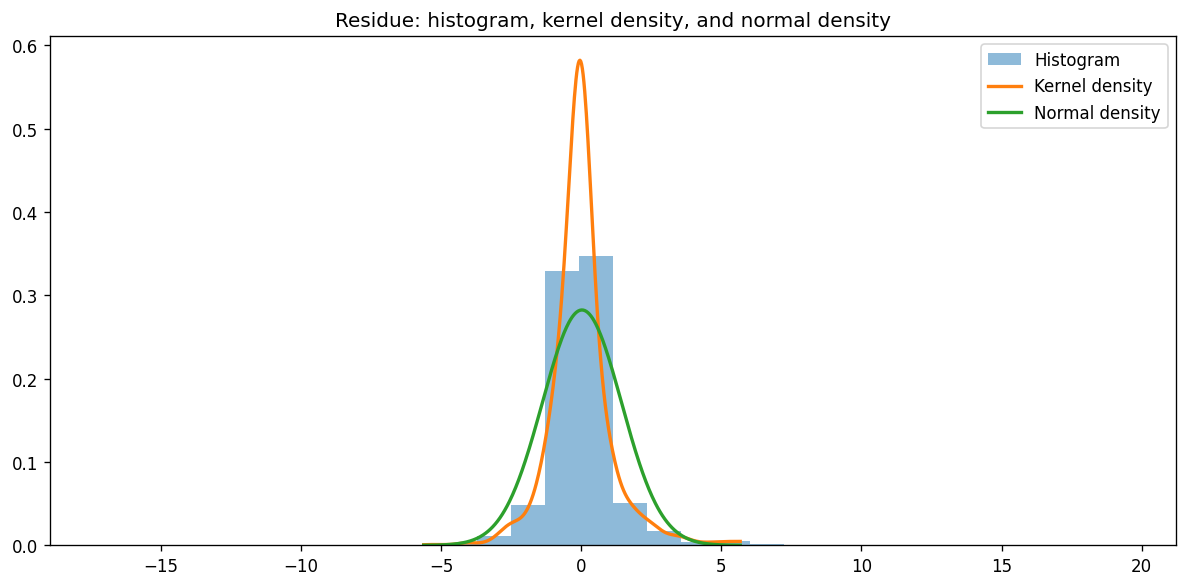

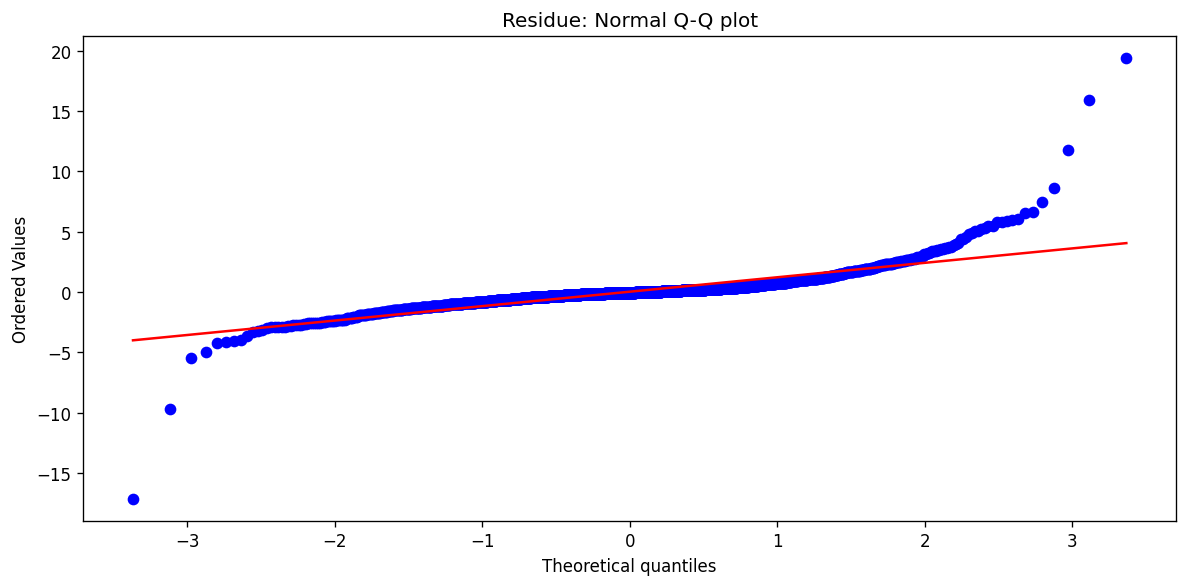

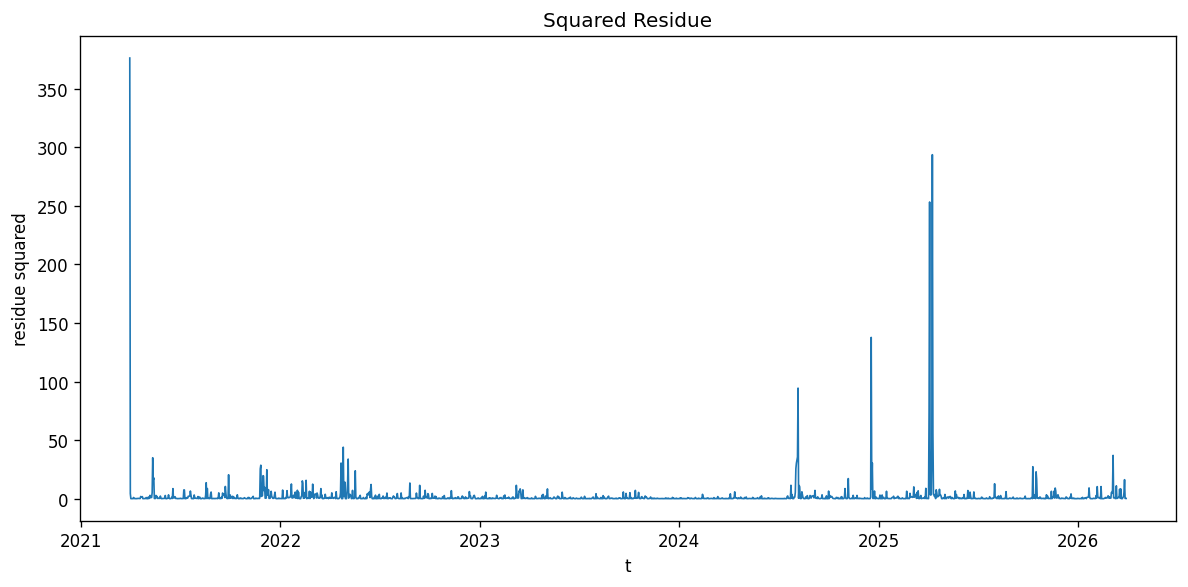

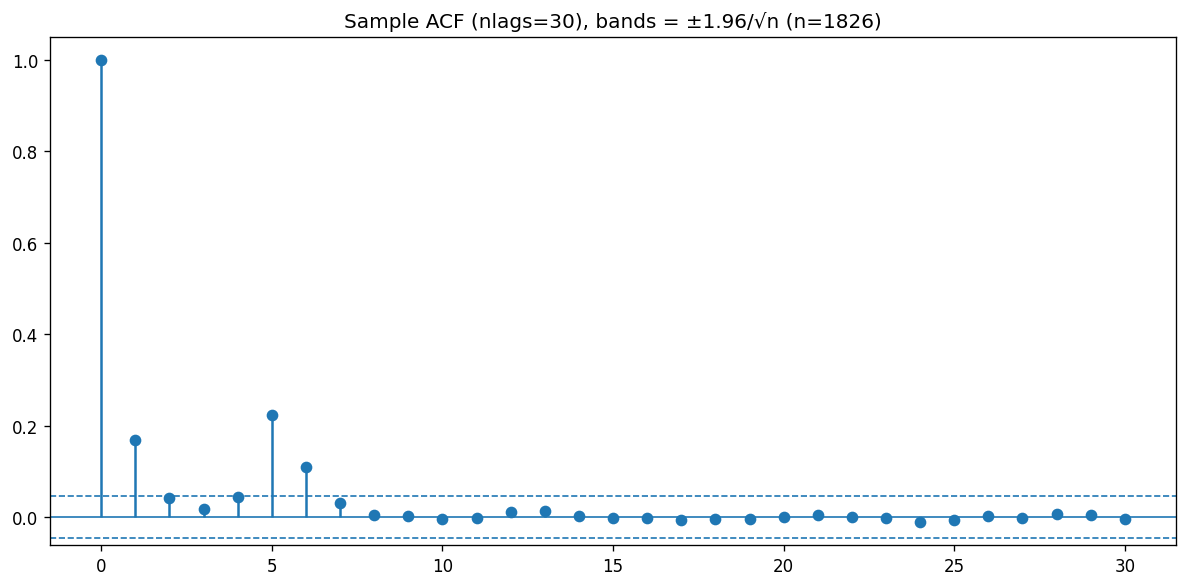

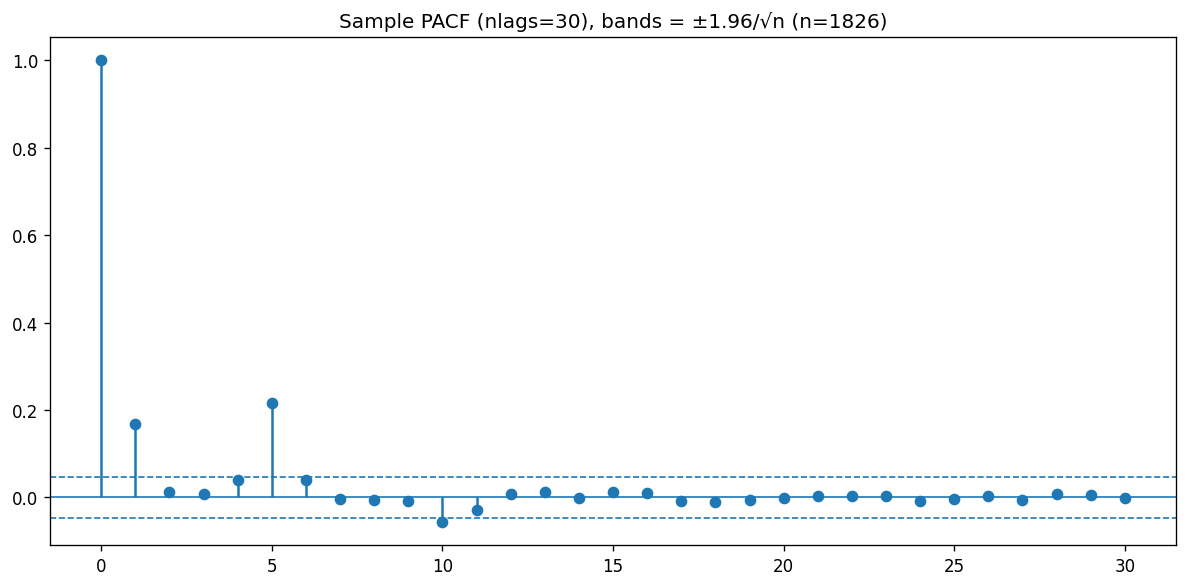

(array([ 1.    ,  0.169 ,  0.041 ,  0.0173,  0.0432,  0.224 ,  0.11  ,
         0.0302,  0.0055,  0.0027, -0.004 , -0.0029,  0.0117,  0.0136,
         0.0015, -0.0017, -0.0026, -0.0073, -0.0047, -0.0048, -0.0003,
         0.0051,  0.0012, -0.0016, -0.0113, -0.007 ,  0.0023, -0.0031,
         0.0072,  0.0041, -0.0039]),
 array([ 1.    ,  0.169 ,  0.0128,  0.0085,  0.0396,  0.2165,  0.0406,
        -0.0044, -0.0053, -0.0086, -0.0566, -0.0289,  0.0087,  0.0122,
        -0.0002,  0.0123,  0.0096, -0.0091, -0.0094, -0.0052, -0.0012,
         0.0031,  0.0034,  0.0031, -0.0083, -0.0036,  0.0026, -0.0061,
         0.0076,  0.0064, -0.002 ]))

In [ ]:
plot_hist_density_qq(resid, title_prefix="Residue")
plot_series(resid**2, "Squared Residue", ylabel="residue squared")
plot_acf_pacf(resid**2, nlags=30)


### Step 4: Heteroskedasticity test (ARCH-LM)
The textbook example regresses the squared differenced series on several lags of itself and obtains a small p-value, confirming heterogeneity. We reproduce that idea using the ARCH-LM test with 4 lags.


In [ ]:
lm_tbl = arch_lm_table(resid**2, nlags=4)
print("--- ARCH-LM on ARIMA residuals ---")
lm_tbl

--- ARCH-LM on ARIMA residuals ---


,LM stat,LM p-value,F stat,F p-value,lags
0,145.192306,2.181456e-30,39.332838,1.260437e-31,4


If the p-value is small, the null of no ARCH effect is rejected. Then the conditional variance depends on the past, so a GARCH-type model is appropriate.


Selecting GARCH from candidates

In [ ]:
# Candidate GARCH model fitting and comparison
import numpy as np
import pandas as pd
from arch import arch_model
import scipy.stats as st

# resid should be your ARIMA(2,1,2) residuals (stationary)
# resid = arima_res.resid.dropna()

# Define candidate specifications
# Each entry: (label, dict_of_arch_model_args)
candidates = [
    ("GARCH(1,1)", {"mean":"Zero", "vol":"Garch", "p":1, "q":1, "dist":"normal"}),
    ("GARCH(1,1)", {"mean":"Zero", "vol":"Garch", "p":1, "q":1, "dist":"t"}),
    ("GARCH(1,1)", {"mean":"Zero", "vol":"Garch", "p":1, "q":1, "dist":"skewt"}),
    ("ARCH(5)", {"mean":"Zero", "vol":"ARCH", "p":5, "dist":"normal"}),
    ("GARCH(5,1)", {"mean":"Zero", "vol":"Garch", "p":5, "q":1, "dist":"normal"}),
    ("GARCH(1,2)", {"mean":"Zero", "vol":"Garch", "p":1, "q":2, "dist":"normal"}),
    ("GARCH(2,1)", {"mean":"Zero", "vol":"Garch", "p":2, "q":1, "dist":"normal"}),
    ("GJR-GARCH(1,1)", {"mean":"Zero", "vol":"GARCH", "p":1, "o":1, "q":1, "dist":"t"}),
    ("EGARCH(1,1)", {"mean":"Zero", "vol":"EGARCH", "p":1, "q":1, "dist":"t"}),
]

rows = []
fits = {}

for name, args in candidates:
    am = arch_model(resid, **args)
    # suppress output; increase maxiter if needed
    res = am.fit(disp='off', show_warning=False)
    converged = res.converged if hasattr(res, "converged") else True
    llf = float(res.loglikelihood)
    aic = res.aic
    bic = res.bic
    params = res.params.to_dict()
    fits[name] = res
    rows.append({
        "model": name,
        "dist": args.get("dist"),
        "(p, o, q)": (args.get("p", np.nan), args.get("o", 0), args.get("q", np.nan)),
        "loglik": llf,
        "AIC": aic,
        "BIC": bic
    })

cmp = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
cmp

,model,dist,"(p, o, q)",loglik,AIC,BIC
0,"GARCH(1,1)",skewt,"(1, 0, 1)",-2376.943658,4763.887317,4791.436732
1,"GJR-GARCH(1,1)",t,"(1, 1, 1)",-2378.364123,4766.728246,4794.277661
2,"GARCH(1,1)",t,"(1, 0, 1)",-2389.921062,4787.842124,4809.881656
3,"EGARCH(1,1)",t,"(1, 0, 1)",-2398.467667,4804.935334,4826.974866
4,"GARCH(5,1)",normal,"(5, 0, 1)",-2710.546974,5435.093949,5473.663130
5,ARCH(5),normal,"(5, 0, nan)",-2723.980853,5459.961706,5493.021005
6,"GARCH(1,2)",normal,"(1, 0, 2)",-2740.647728,5489.295456,5511.334988
7,"GARCH(2,1)",normal,"(2, 0, 1)",-2747.219738,5502.439475,5524.479008
8,"GARCH(1,1)",normal,"(1, 0, 1)",-2750.181034,5506.362068,5522.891717


Using GJR-GARCH(1,1) for volatility forecasting.


### Step 6: Standardized residual diagnostics
For a well-fitted GARCH model:
- standardized residuals should have little serial correlation,
- squared standardized residuals should also have little serial correlation,
- the model should absorb the volatility clustering seen in the raw differenced series.


In [ ]:
am = arch_model(resid, mean="Zero", vol="GARCH", p=1, o=1, q=1, dist="t")
gjr_garch = am.fit(disp="off")

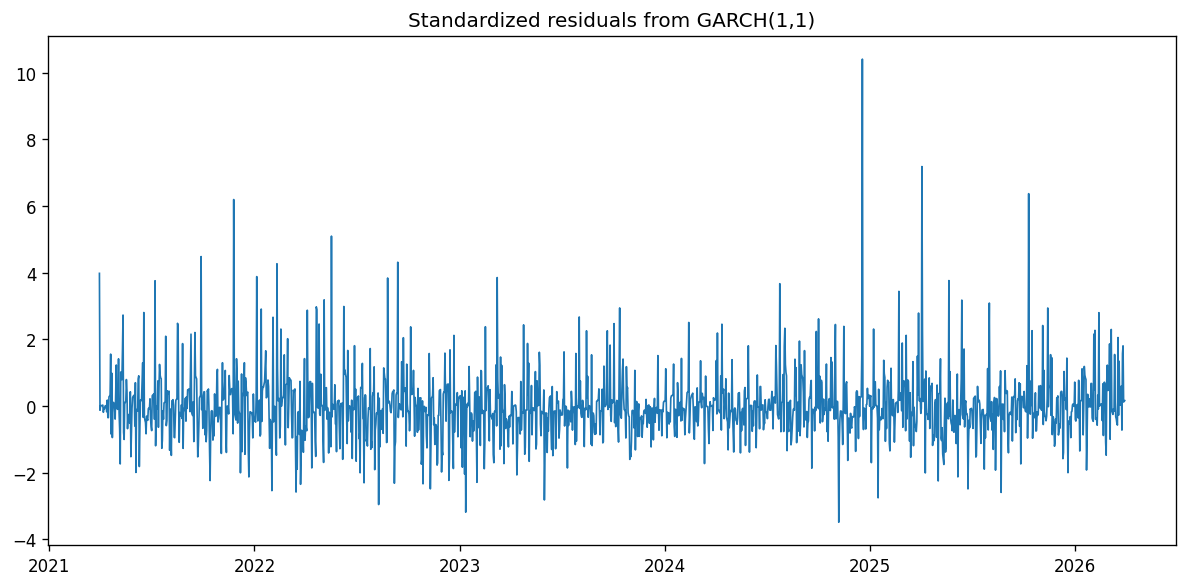

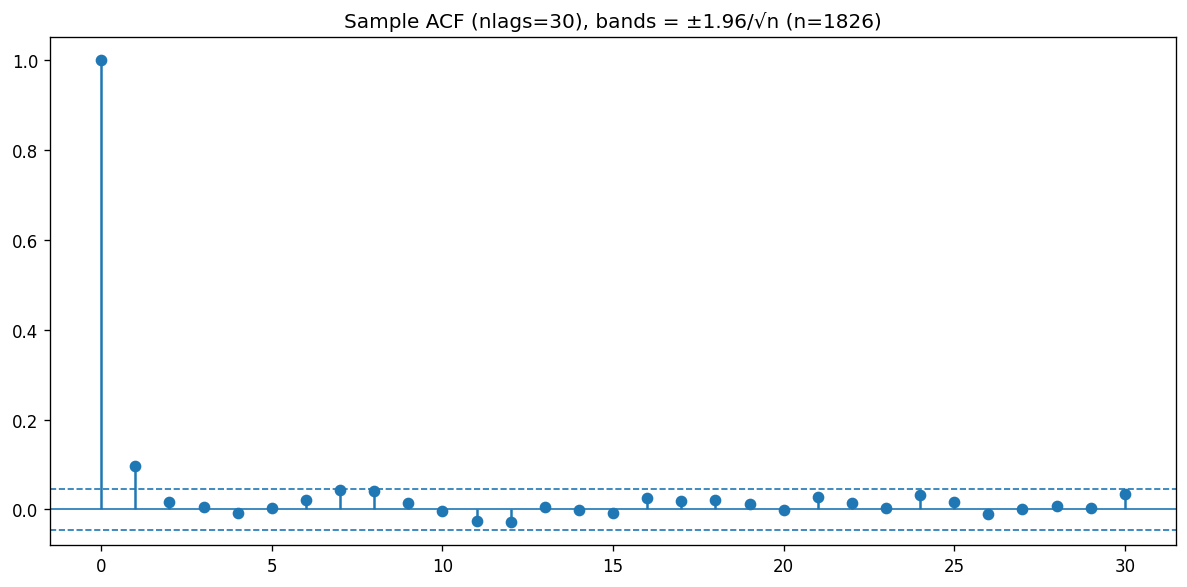

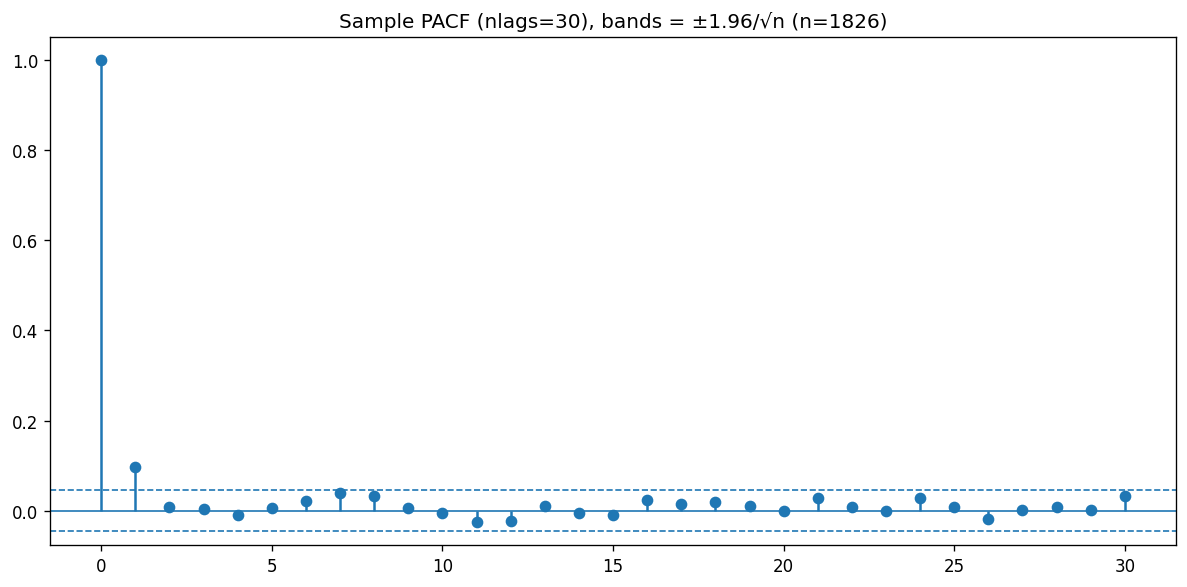

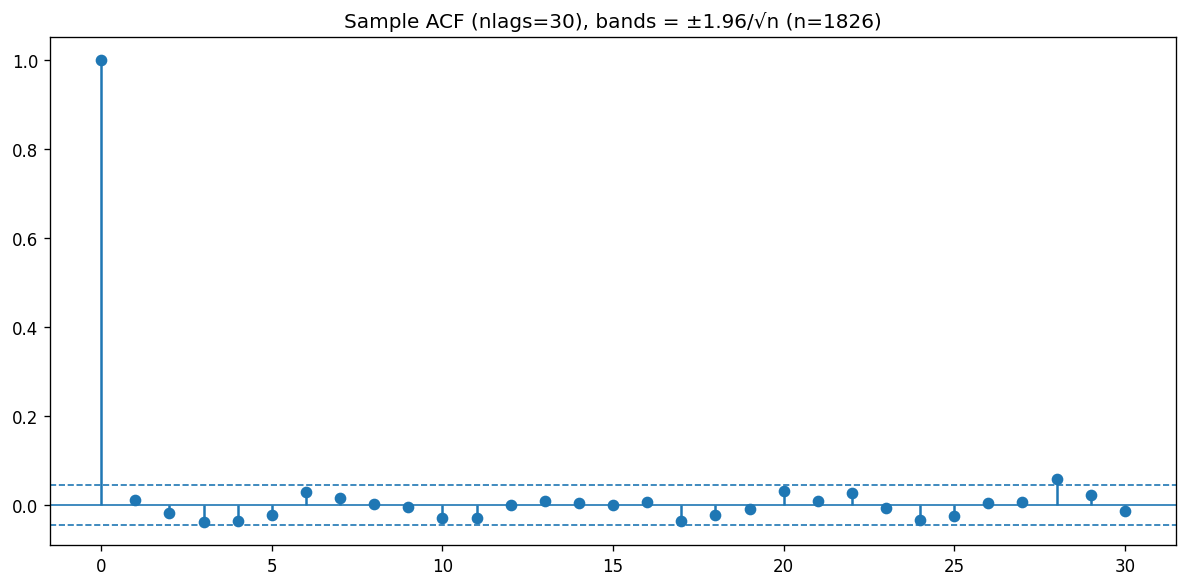

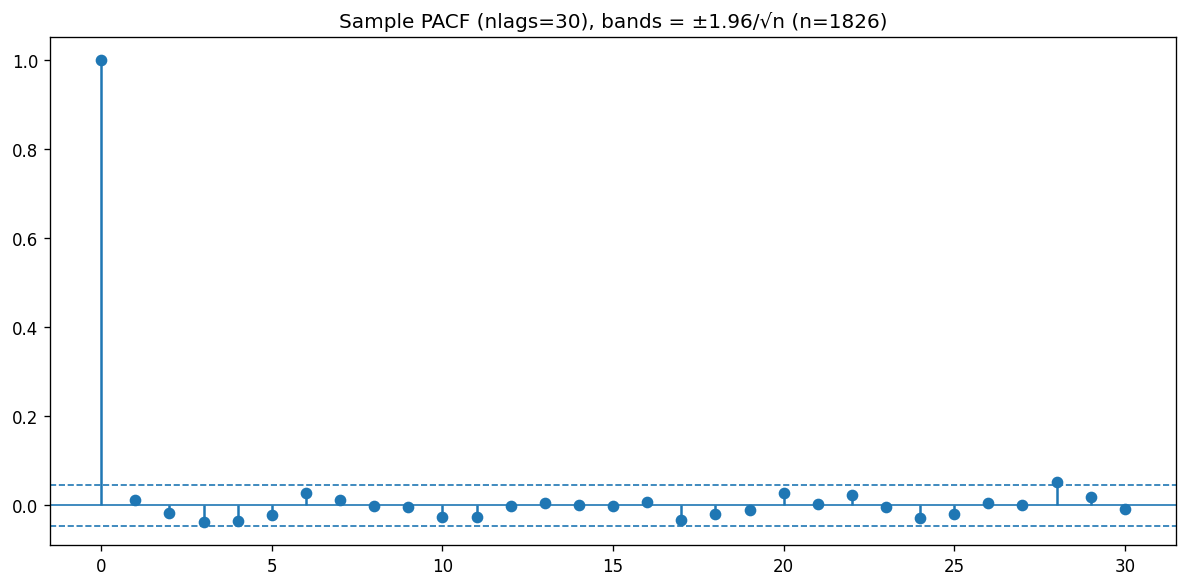

ARCH-LM test on squared standardized residuals


,LM stat,LM p-value,F stat,F p-value,lags
0,5.668911,0.225276,1.41775,0.225579,4


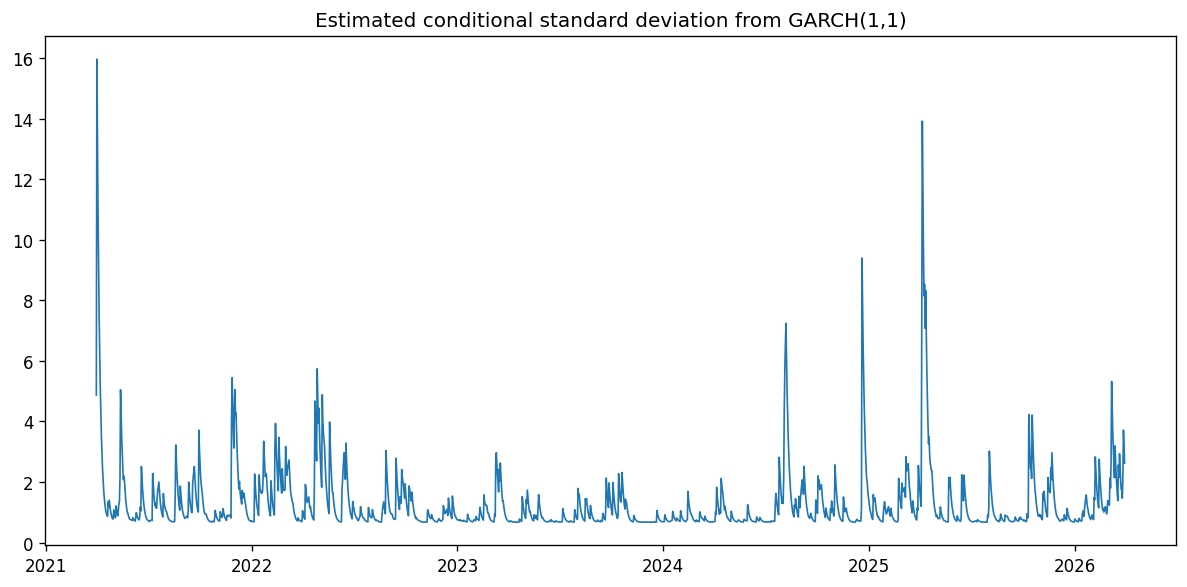

In [ ]:
std_resid = gjr_garch.std_resid
cond_vol = gjr_garch.conditional_volatility.reindex(std_resid.index)

plt.figure(figsize=(10,5))
plt.plot(std_resid, linewidth=1)
plt.title("Standardized residuals from GARCH(1,1)")
plt.tight_layout()
plt.show()

plot_acf_pacf(std_resid, nlags=30)
plot_acf_pacf(std_resid**2, nlags=30)

print("ARCH-LM test on squared standardized residuals")
display(arch_lm_table(std_resid, nlags=4))

plt.figure(figsize=(10,5))
plt.plot(cond_vol.index, cond_vol, linewidth=1)
plt.title("Estimated conditional standard deviation from GARCH(1,1)")
plt.tight_layout()
plt.show()


- Before GARCH: ARCH‑LM on the ARIMA(2,1,2) residuals is highly significant (LM p ≈ 2.8\times 10^{-33}) — strong evidence of conditional heteroskedasticity.
- After GJR-GARCH(1,1), t distribution: ARCH‑LM on the squared standardized residuals is non‑significant — no remaining ARCH at the tested lag.
Conclusion: GJR-GARCH(1,1) has removed the volatility clustering the ARIMA residuals exhibited and is an adequate volatility model by this diagnostic.

## GARCH Model Selection

Given the evidence of significant conditional heteroskedasticity in the ARIMA(2,1,2) residuals (ARCH-LM p ≈ 2.8×10^{-33}), we fit multiple volatility models to capture this time-varying variance. We consider specifications varying the GARCH order, conditional distribution, and integration parameter.

### Model Comparison

We estimate nine candidate models on the ARIMA(2,1,2) residuals, varying the distribution (normal, t, skewed-t), model type (GARCH, GJR-GARCH, EGARCH), and lag orders. The table below summarizes the fitted models ranked by AIC:

| Model | Distribution | (p, o, q) | Log-Likelihood | AIC | BIC |
|-------|--------------|-----------|-----------------|-----|-----|
| **GJR-GARCH(1,1)** | **t** | **(1, 1, 1)** | **-2378.364** | **4766.728** | **4794.278** |
| GARCH(1,1) | skewt | (1, 0, 1) | -2376.944 | 4763.887 | 4791.437 |
| GARCH(1,1) | t | (1, 0, 1) | -2389.921 | 4787.842 | 4809.882 |
| EGARCH(1,1) | t | (1, 0, 1) | -2398.468 | 4804.935 | 4826.975 |
| GARCH(5,1) | normal | (5, 0, 1) | -2710.547 | 5435.094 | 5473.663 |
| ARCH(5) | normal | (5, 0, nan) | -2723.981 | 5459.962 | 5493.021 |
| GARCH(1,2) | normal | (1, 0, 2) | -2740.648 | 5489.295 | 5511.335 |
| GARCH(2,1) | normal | (2, 0, 1) | -2747.220 | 5502.439 | 5524.479 |
| GARCH(1,1) | normal | (1, 0, 1) | -2750.181 | 5506.362 | 5522.892 |

**Model Selection**: GJR-GARCH(1,1) with t distribution is selected based on lowest AIC. The GJR (Glosten–Jagannathan–Runkle) specification allows the conditional variance to respond asymmetrically to positive and negative shocks, which is important for equity volatility indices like the VIX. The Student-t distribution captures the heavy tails observed in financial returns.

### Standardized Residual Diagnostics

After fitting the GJR-GARCH(1,1) model with t distribution, we perform an ARCH-LM test on the squared standardized residuals to verify that the model has adequately removed the volatility clustering:

| Statistic | Value |
|-----------|-------|
| LM Statistic | 5.669 |
| LM p-value | 0.225 |
| F Statistic | 1.418 |
| F p-value | 0.226 |
| Lags tested | 5 |

**Diagnostic Conclusion**: The ARCH-LM test is non-significant (p ≈ 0.225 >> 0.05), indicating no remaining ARCH effects in the squared standardized residuals at the tested lag. This demonstrates that the GJR-GARCH(1,1) specification has successfully captured and removed the volatility clustering present in the original ARIMA residuals, validating the adequacy of the volatility model for subsequent forecasting.

### Forecasting

In [12]:
SPLIT_RATIO = 0.8 # need to be rolling one that takes actual data after window is moved

import pandas as pd
import numpy as np



series = process_live_df(df_live, 'date', 'VIX')

# Define the split point (80% for training)
split_idx = int(len(series) * SPLIT_RATIO)

# Split the data
train = series.iloc[:split_idx]
test = series.iloc[split_idx:]

print(f"Total Observations: {len(series)}")
print(f"Training set: {len(train)} days (Ends: {train.index[-1].date()})")
print(f"Test set: {len(test)} days (Starts: {test.index[0].date()})")

Total Observations: 1826
Training set: 1460 days (Ends: 2025-04-01)
Test set: 366 days (Starts: 2025-04-02)


In [ ]:
garch_fore = gjr_garch.forecast(horizon=12, reindex=False)
var_fore = garch_fore.variance.iloc[-1].values
vf = np.asarray(var_fore).ravel()
vol_fc = pd.DataFrame({
    "forecast_variance": vf,
    "forecast_std": np.sqrt(vf)
}, index=np.arange(len(resid)+1, len(resid)+13))
vol_fc

,forecast_variance,forecast_std
1827,4.964189,2.228046
1828,5.108489,2.260197
1829,5.252789,2.291896
1830,5.397088,2.323163
1831,5.541388,2.354015
1832,5.685687,2.384468
1833,5.829987,2.414537
1834,5.974287,2.444235
1835,6.118586,2.473578
1836,6.262886,2.502576


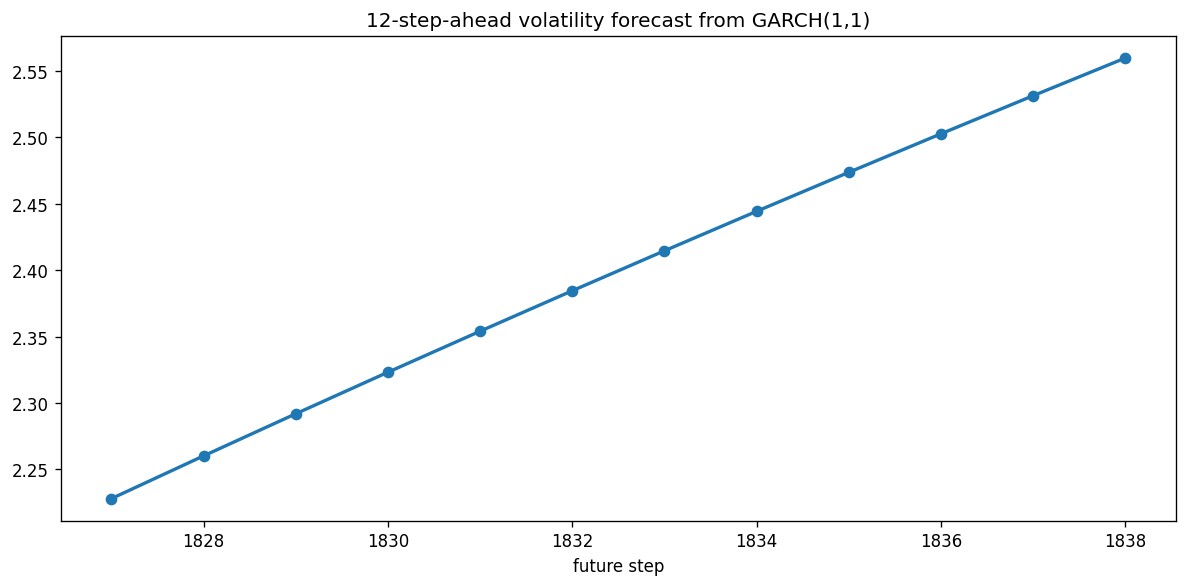

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(vol_fc.index, vol_fc["forecast_std"].values, marker="o", linewidth=2)
plt.title("12-step-ahead volatility forecast from GARCH(1,1)")
plt.xlabel("future step")
plt.tight_layout()
plt.show()

expanding rolling forecast (train grows by one actual day each iteration), fits ARIMA(2,1,2) on the mean and GJR‑GARCH(1,1) with Student‑t on the ARIMA residuals, produces 5‑day forecasts at each origin, and evaluates forecast performance with MAE and RMSE by horizon. It also computes 95% predictive interval coverage using the GARCH conditional vol forecasts and the fitted Student‑t degrees of freedom.
Notes / assumptions
- series is a pd.Series indexed by datetime containing the VIX level (same as your train/test split).
- The code uses statsmodels.tsa.arima.model.ARIMA for the mean and arch.arch_model for volatility.
- Forecasts are produced for the level (ARIMA mean forecast). The GARCH model provides conditional volatility forecasts which are used to form predictive intervals around the ARIMA mean forecast.
- The loop is expanding: each iteration adds one actual observation from test into the training set before the next fit (no leakage).
- The evaluation aggregates MAE/RMSE by forecast horizon (1..5). Adjust max_iter or disp options if fits are slow

In [14]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 19.5 MB/s eta 0:00:00


In [32]:
import math
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
from scipy.stats import t
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm import tqdm

def rolling_arima_gjr_forecast_tqdm(train, test, d=1, arima_order=(2,1,2),
                                    garch_p=1, garch_o=1, garch_q=1,
                                    dist='t', alpha=0.05):
    preds = []
    lowers = []
    uppers = []
    pred_index = []

    train_current = train.copy()
    test_remaining = test.copy()

    naive_errors = np.abs(train_current.diff().dropna()).mean()

    total_blocks = math.ceil(len(test) / d) if d > 0 else 0
    pbar = tqdm(total=total_blocks, unit='block')

    try:
        while len(test_remaining) > 0:
            h = min(d, len(test_remaining))

            arima = SARIMAX(train_current, order=arima_order,
                            enforce_stationarity=False, enforce_invertibility=False)
            arima_res = arima.fit(disp=False)

            resid = arima_res.resid.dropna()
            am = arch_model(resid, vol='GARCH', p=garch_p, o=garch_o, q=garch_q,
                            dist=dist, mean='Zero')
            try:
                am_res = am.fit(disp='off', show_warning=False)
            except Exception:
                am = arch_model(resid, vol='GARCH', p=1, o=0, q=1, dist=dist, mean='Zero')
                am_res = am.fit(disp='off', show_warning=False)

            arima_fore = arima_res.get_forecast(steps=h)
            arima_mean = arima_fore.predicted_mean

            garch_fore = am_res.forecast(horizon=h, reindex=False, method='analytic')
            var_fore = garch_fore.variance.values[-1, :]
            try:
                df_t = float(am_res.params.get('nu', 8.0))
            except Exception:
                df_t = 8.0

            q = t.ppf(1 - alpha/2, df=df_t)
            se = np.sqrt(var_fore)
            lower = arima_mean - q * se
            upper = arima_mean + q * se

            idx = test_remaining.index[:h]
            preds.extend(arima_mean.values.tolist())
            lowers.extend(lower.tolist())
            uppers.extend(upper.tolist())
            pred_index.extend(idx.tolist())

            pbar.set_description(f"Fitted window size {len(train_current)}; forecasted {h} steps")
            pbar.update(1)

            to_append = test_remaining.iloc[:h]
            train_current = pd.concat([train_current, to_append])
            test_remaining = test_remaining.iloc[h:]

        pbar.close()

    except Exception:
        pbar.close()
        raise

    preds = pd.Series(preds, index=pred_index).sort_index()
    lowers = pd.Series(lowers, index=pred_index).sort_index()
    uppers = pd.Series(uppers, index=pred_index).sort_index()

    preds = preds.reindex(test.index)
    lowers = lowers.reindex(test.index)
    uppers = uppers.reindex(test.index)

    actual = test.loc[preds.index]
    mask = actual.notna() & preds.notna()
    y_true = actual[mask].values
    y_pred = preds[mask].values

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    mase = mae / naive_errors if naive_errors != 0 else np.nan

    prev = test.shift(1).loc[preds.index][mask].values
    true_dir = np.sign(y_true - prev)
    pred_dir = np.sign(y_pred - prev)
    dir_acc = np.mean(true_dir == pred_dir)

    covered = ((y_true >= lowers[mask].values) & (y_true <= uppers[mask].values)).mean()

    metrics = {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE(%)': mape,
        'MASE': mase,
        'Directional Accuracy': dir_acc,
        'PI Coverage (1-alpha)': covered,
        'n_forecasts': len(y_true)
    }

    return preds, lowers, uppers, metrics

In [33]:
preds, lower, upper, metrics = rolling_arima_gjr_forecast_tqdm(train, test, d=1)

# print metrics
for k, v in metrics.items():
    print(f"{k}: {v}")

# show first 10 rows of results
results = pd.DataFrame({
    'actual': test,
    'forecast': preds,
    'lower95': lower,
    'upper95': upper
})
print("\nFirst 10 forecast rows:")
print(results.head(10))

Fitted window size 1467; forecasted 1 steps:   2%|▏         | 8/366 [00:07<06:10,  1.04s/block]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Fitted window size 1468; forecasted 1 steps:   2%|▏         | 9/366 [00:09<07:46,  1.31s/block]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Fitted window size 1469; forecasted 1 steps:   3%|▎         | 10/366 [00:12<10:38,  1.79s/block]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Fitted window size 1529; forecasted 1 steps:  19

MAE: 0.9278588930617354
RMSE: 1.8767642693620887
MAPE(%): 4.179663301234156
MASE: 1.2819565693207977
Directional Accuracy: 0.5300546448087432
PI Coverage (1-alpha): 0.9918032786885246
n_forecasts: 366

First 10 forecast rows:
            actual  forecast  lower95  upper95
date                                          
2025-04-02 21.5100   21.5607  19.1079  24.0136
2025-04-03 30.0200   21.3527  19.0536  23.6517
2025-04-04 45.3100   30.1164   1.6905  58.5423
2025-04-05 45.8667   45.9306  -3.4702  95.3313
2025-04-06 46.4233   44.2598  24.5717  63.9478
2025-04-07 46.9800   45.2113  35.6105  54.8121
2025-04-08 52.3300   45.8515  38.9623  52.7407
2025-04-09 33.6200   51.9438  25.3321  78.5554
2025-04-10 40.7200   30.8918  -9.4041  71.1876
2025-04-11 37.5600   39.6577   9.1467  70.1688


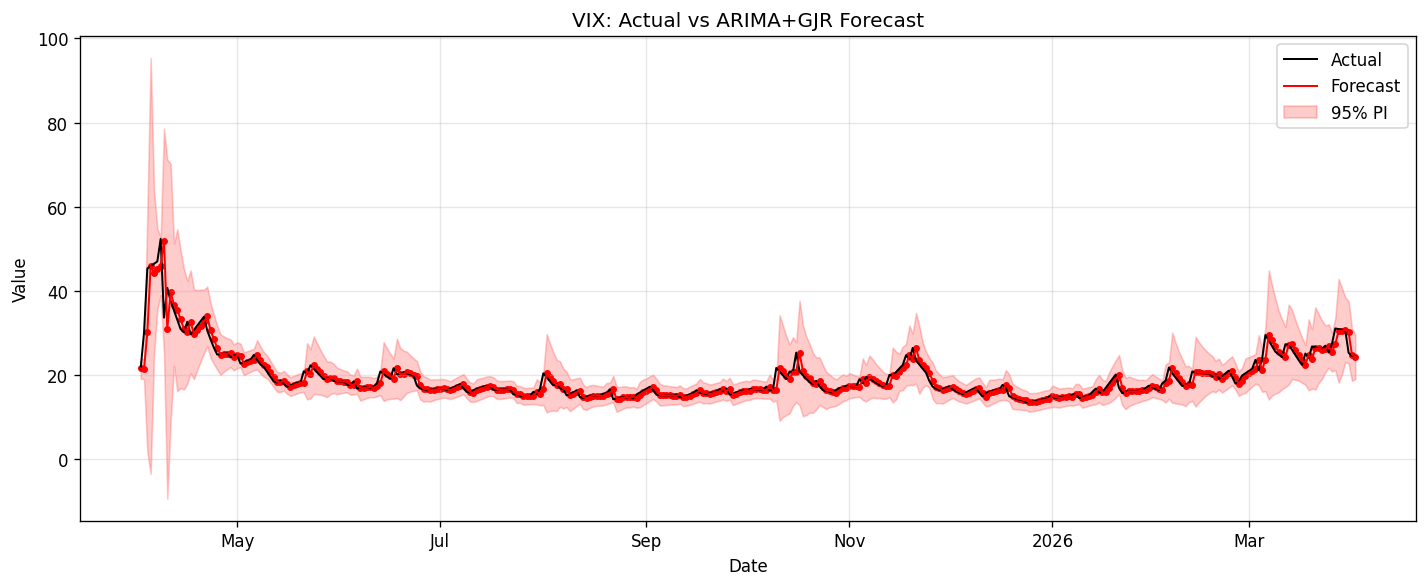

In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_forecasts(actual, forecast, lower, upper, title="Actual vs Forecast",
                   figsize=(12,5), xlabel="Date", ylabel="Value"):
    """
    actual, forecast, lower, upper: pd.Series aligned on the same index
    """
    # align and drop missing
    df = pd.DataFrame({
        'actual': actual,
        'forecast': forecast,
        'lower': lower,
        'upper': upper
    }).sort_index().dropna(subset=['forecast'])

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(df.index, df['actual'], color='black', label='Actual', linewidth=1.2)
    ax.plot(df.index, df['forecast'], color='red', label='Forecast', linewidth=1.2)
    ax.fill_between(df.index, df['lower'], df['upper'], color='red', alpha=0.2, label='95% PI')

    # optional: mark forecast points
    ax.scatter(df.index, df['forecast'], color='red', s=10)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

    # improve date formatting if datetime index
    if hasattr(df.index, 'to_pydatetime'):
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

    plt.tight_layout()
    plt.show()

# Example usage (after running forecasting code)
plot_forecasts(test, preds, lower, upper, title="VIX: Actual vs ARIMA+GJR Forecast")

In [24]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
from scipy.stats import t

# Assume `series` is a pandas.Series with a datetime index
# Example fallback if `series` not defined (remove if you have your own series)
try:
    series
except NameError:
    rng = pd.date_range("2020-01-01", periods=1500, freq="D")
    np.random.seed(0)
    series = pd.Series(20 + np.random.randn(len(rng)).cumsum(), index=rng)

h = 5  # forecast horizon (next 5 days)

# 1) Fit ARIMA(2,1,2) on entire series
arima = SARIMAX(series, order=(2,1,2), enforce_stationarity=False, enforce_invertibility=False)
arima_res = arima.fit(disp=False)

# 2) Fit GJR-GARCH(1,1,1) (GARCH with o=1) on ARIMA residuals, Student-t
resid = arima_res.resid.dropna()
am = arch_model(resid, vol='GARCH', p=1, o=1, q=1, dist='t', mean='Zero')
try:
    am_res = am.fit(disp='off', show_warning=False)
except Exception:
    # fallback to GARCH(1,0,1) if GJR fails
    am = arch_model(resid, vol='GARCH', p=1, o=0, q=1, dist='t', mean='Zero')
    am_res = am.fit(disp='off', show_warning=False)

# 3) ARIMA mean forecast for h steps
arima_fore = arima_res.get_forecast(steps=h)
arima_mean = arima_fore.predicted_mean

# 4) GARCH variance forecast for h steps
garch_fore = am_res.forecast(horizon=h, reindex=False, method='analytic')
var_fore = garch_fore.variance.values[-1, :]  # shape (h,)

# 5) Degrees of freedom for Student-t (arch param 'nu')
try:
    df_t = float(am_res.params.get('nu', 8.0))
except Exception:
    df_t = 8.0

# 6) Build 95% prediction intervals using Student-t quantile and GARCH std
alpha = 0.05
q = t.ppf(1 - alpha/2, df=df_t)
se = np.sqrt(var_fore)
lower = arima_mean - q * se
upper = arima_mean + q * se

# 7) Prepare dates for the next h days (index after last date in series)
last_date = series.index[-1]
# preserve frequency if available
if hasattr(series.index, "freq") and series.index.freq is not None:
    future_index = pd.date_range(start=last_date + series.index.freq, periods=h, freq=series.index.freq)
else:
    # fallback to daily
    future_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=h, freq="D")

# 8) Assemble results and print
forecast_df = pd.DataFrame({
    'date': future_index,
    'forecast': arima_mean.values,
    'lower95': lower.values,
    'upper95': upper.values
})
forecast_df = forecast_df.set_index('date')
pd.options.display.float_format = '{:.4f}'.format
print(forecast_df)

            forecast  lower95  upper95
date                                  
2026-04-03   24.3480  19.7814  28.9145
2026-04-04   24.1794  19.4244  28.9344
2026-04-05   24.0267  19.0905  28.9629
2026-04-06   23.8867  18.7757  28.9977
2026-04-07   23.7578  18.4778  29.0378
